In [1]:
import toml
import os
import sys
workspace_root = os.getcwd()
sys.path.insert(0, workspace_root + "/../../..")
from analysis import Analysis

In [2]:
# ANALYSIS SPECIFIC DIRECTORIES
ana_directory = "../../1muNp0pi_Nge1_uncontained"
data_file = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root'


Processing systematics for sample: mc
--Systematic(statistical, None)--
	Fractional uncertainty: 0.42%
--Systematic(stats, Stat.)--
	Fractional uncertainty: 0.42%
--Systematic(MC_total, All Systematics (No G4))--
	Fractional uncertainty: 0.42%

Processing systematics for sample: mc_nonmatched

Processing systematics for sample: onbeam

Processing systematics for sample: offbeam

Processing systematics for sample: rock
Setting weight for mc to 3.29e-02
Setting weight for mc_nonmatched to 3.29e-02
Setting weight for onbeam to 1.00e+00
Setting weight for offbeam to 9.53e-02
Setting weight for rock to 1.38e+00
Fractional - Min: 1.80%, Max: 6.38%
Fractional - Min: 1.34%, Max: 3.41%
Fractional - Min: 1.09%, Max: 3.01%


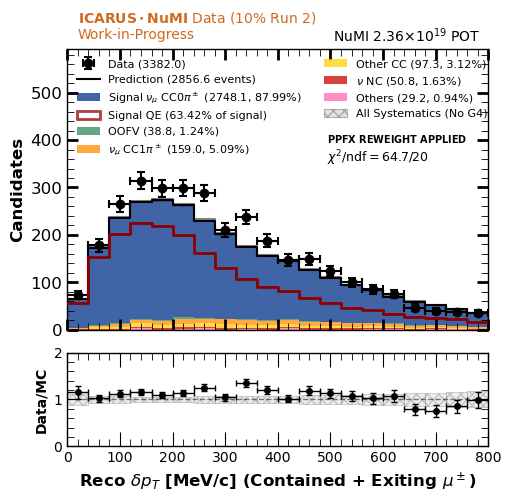

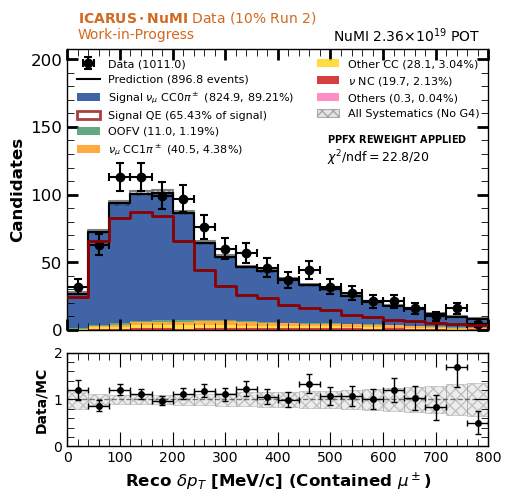

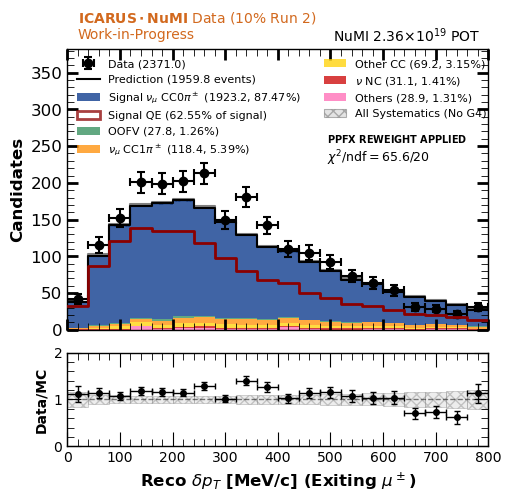

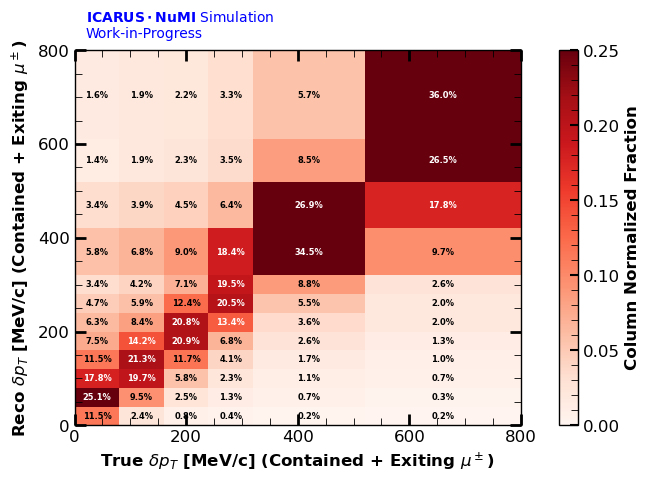

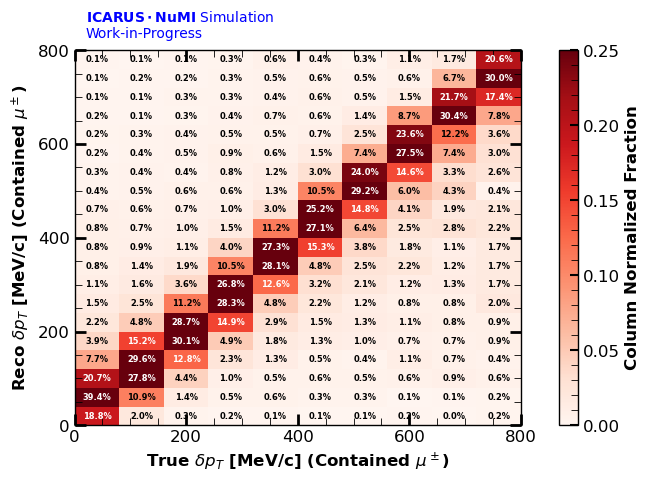

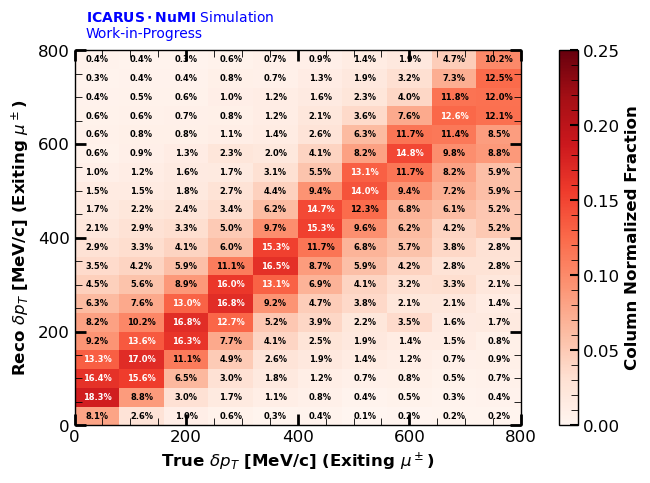

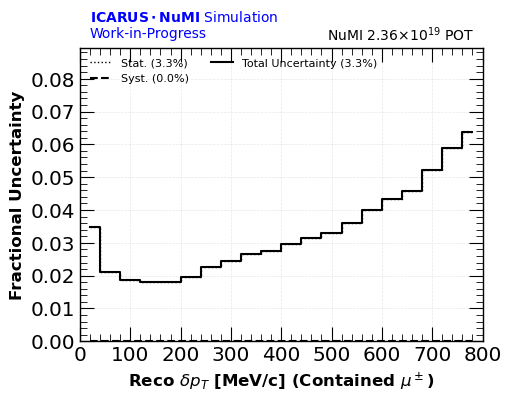

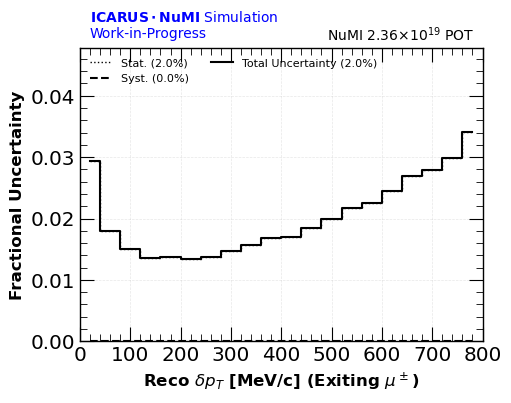

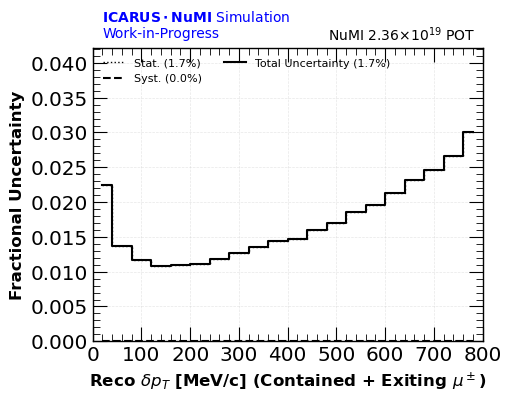

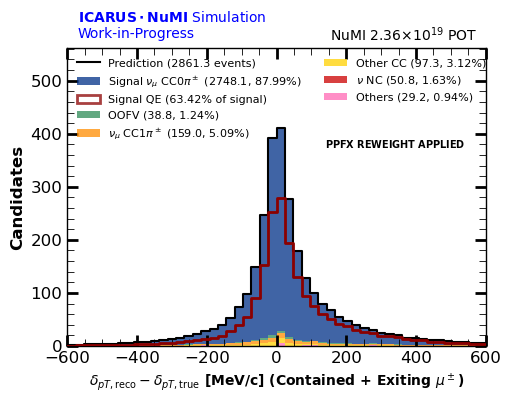

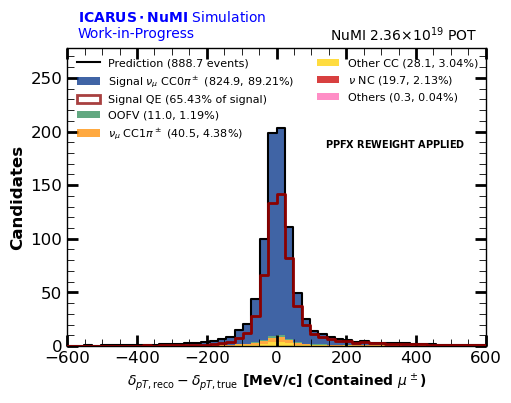

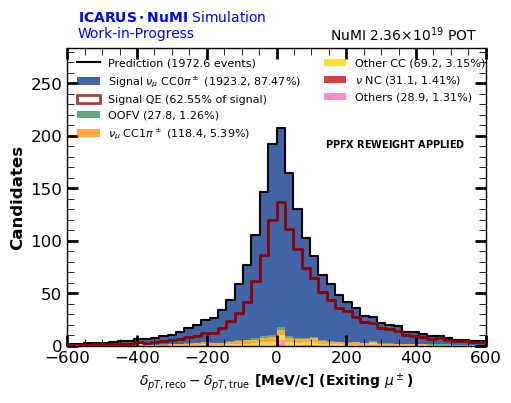

In [3]:
analysis = Analysis(ana_directory + '/dpT/dpT.toml', data_file)
analysis.run(close_figs=False)

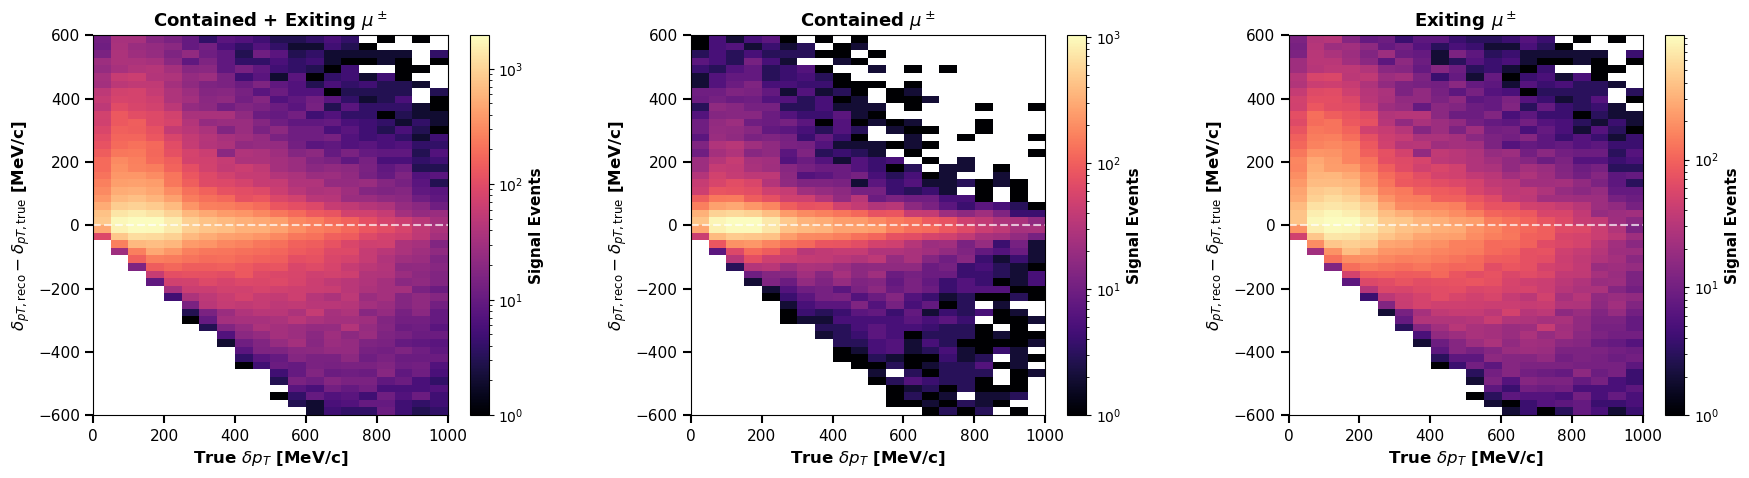

In [4]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# File and tree
fpath = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_gundam_withPCA.root'

with uproot.open(fpath) as f:
    tree = f['events/full/selected']
    reco_dpT       = tree['reco_dpT_lp'].array(library='np')
    true_dpT       = tree['true_dpT_lp_genie'].array(library='np')
    true_category  = tree['true_category'].array(library='np')
    muon_contained = tree['reco_leading_muon_containment'].array(library='np')

# Signal categories
signal_mask = np.isin(true_category, [0, 1, 3, 4])

# Valid kinematics mask
valid_mask = (
    np.isfinite(true_dpT) &
    np.isfinite(reco_dpT) &
    (reco_dpT < 5000) &
    (true_dpT < 5000)
)

# Compute absolute residual
abs_residual = reco_dpT - true_dpT

# Combined, contained, exiting masks
combined_mask  = signal_mask & valid_mask
contained_mask = signal_mask & valid_mask & (muon_contained == 1)
exiting_mask   = signal_mask & valid_mask & (muon_contained == 0)

# Binning
x_bins = np.linspace(0, 1000, 21)
y_bins = np.linspace(-600, 600, 51)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(left=0.07, right=0.98, top=0.88, bottom=0.12, wspace=0.35)

titles = [
    r'Contained + Exiting $\mu^\pm$',
    r'Contained $\mu^\pm$',
    r'Exiting $\mu^\pm$'
]
masks = [combined_mask, contained_mask, exiting_mask]

for ax, mask, title in zip(axes, masks, titles):
    h, xedges, yedges = np.histogram2d(
        true_dpT[mask],
        abs_residual[mask],
        bins=[x_bins, y_bins]
    )

    im = ax.imshow(
        h.T,
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        aspect='auto',
        origin='lower',
        norm=mcolors.LogNorm(vmin=1, vmax=h.max()),
        cmap='magma'
    )

    ax.axhline(y=0, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.set_xlabel(r'True $\delta p_T$ [MeV/c]', fontsize=12, fontweight='bold')
    ax.set_ylabel(r'$\delta_{pT,\mathrm{reco}} - \delta_{pT,\mathrm{true}}$ [MeV/c]',
                  fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=11, size=6, width=1.5)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Signal Events', fontsize=11, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)
plt.savefig('pdf/dpT_resolution_vs_true_dpT.pdf', bbox_inches='tight', dpi=150)
plt.show()


Processing systematics for sample: mc
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA1CCQE, None)--
	Fractional uncertainty: 5.76%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA1CCQE_sigma, None)--
	Fractional uncertainty: 79.77%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA2CCQE, None)--
	Fractional uncertainty: 0.97%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA2CCQE_sigma, None)--
	Fractional uncertainty: 80.23%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA3CCQE, None)--
	Fractional uncertainty: 2.12%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA3CCQE_sigma, None)--
	Fractional uncertainty: 78.64%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA4CCQE, None)--
	Fractional uncertainty: 0.56%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA4CCQE_sigma, None)--
	Fractional uncertainty: 78.62%
--Systematic(GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape, None)--
	Fractional uncertainty: 0.09%
--Systematic(GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape_sigma

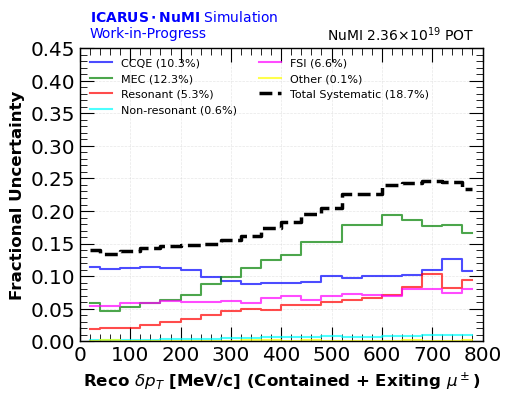

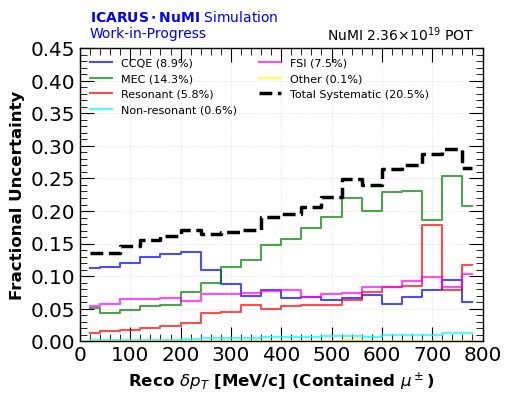

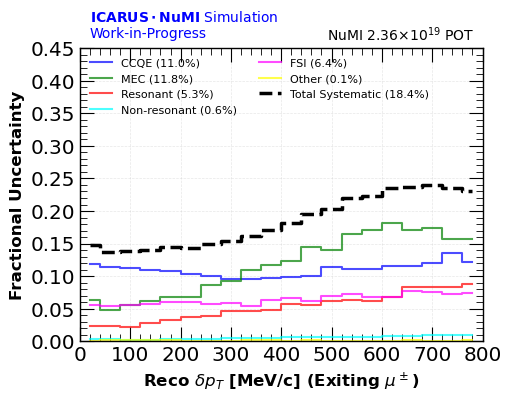

In [6]:
analysis = Analysis(ana_directory + '/dpT/dpT_xSecUncertainty.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Delta p_T cross-section uncertainties plot expanded
analysis = Analysis(ana_directory + '/dpT/dpT_xSecUncertainty_Exp.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Delta p_T flux uncertainties plot
analysis = Analysis(ana_directory + '/dpT/dpT_FluxUncertainty.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Delta p_T flux uncertainties plot expanded
analysis = Analysis(ana_directory + '/dpT/dpT_FluxUncertainty_Exp.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Delta p_T detector uncertainties plot
analysis = Analysis(ana_directory + '/dpT/dpT_DetectorUncertainty.toml', data_file)
analysis.run(close_figs=False)

true signal: 87976; fully contained: 25925 (29.5%)

  true dpT bin  N_full    bias    res |   N_nfc    bias    res
    0-50          1512    25.6   48.2 |    3665   113.5  161.8
   50-100         3408    10.6   44.8 |    7385    79.2  151.8
  100-150         3955     8.0   44.0 |    8493    57.0  148.6
  150-200         3783     3.2   41.6 |    8057    41.5  141.3
  200-250         2920     1.5   41.2 |    6089    26.7  134.0
  250-300         1745     0.6   42.9 |    4020    13.3  129.1
  300-400         2719    -3.0   44.5 |    6387     1.5  133.2
  400-500         2094    -5.5   46.7 |    5350    -8.4  146.2
  500-650         2055   -11.2   61.6 |    5564   -26.1  162.0
  650-800         1027   -15.8   76.3 |    3633   -51.5  194.5


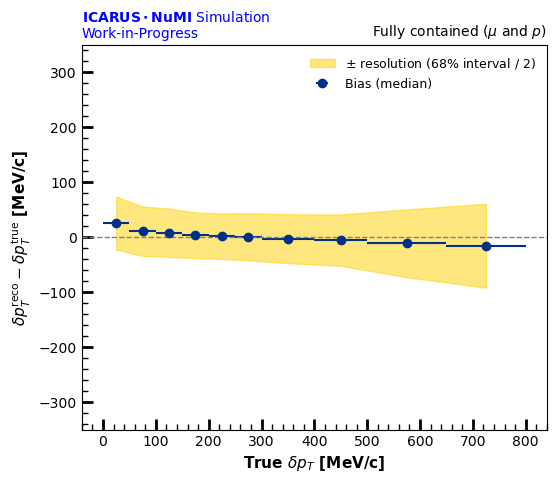

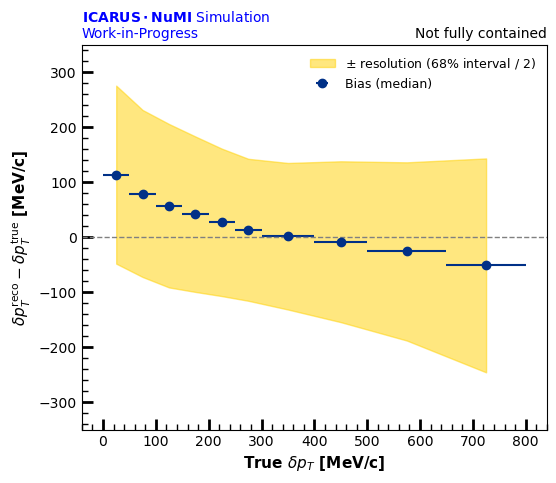

In [2]:
# dpT resolution vs true dpT, split by event containment -- reviewer
# question (London, Fig 16):
# "reco_delta_pT - true_delta_pT in bins of true_delta_pT may be the best way
# to investigate the resolution for this variable. It would also be a good
# investigation of the above points about MCS resolutions to look at the
# delta_pT resolutions for fully contained and non-fully-contained events
# separately."
#
# Fully contained = leading muon AND leading proton contained (29.5% of the
# selected true-signal sample). Bias = median of reco - true per true-dpT bin;
# resolution = half the central 68% interval.

import os
import uproot
import numpy as np
import matplotlib.pyplot as plt

NAVY, GOLD, RED = "#003087", "#FFD100", "#CC0000"
SYST_FILE = (
    "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
    "My Drive/\U0001F3DB PhD Repository/\U0001F680 Research/\U0001F916 Experiments&Projects/"
    "ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root"
)

t = uproot.open(SYST_FILE)["events/full/selected"]
a = t.arrays(["true_category", "reco_leading_muon_containment",
              "reco_leading_proton_containment", "reco_dpT_lp",
              "true_dpT_lp_genie"], library="np")
sig = np.isin(a["true_category"], [0, 1, 3, 4]) & (a["true_dpT_lp_genie"] >= 0)
full = (a["reco_leading_muon_containment"] == 1) & (a["reco_leading_proton_containment"] == 1)
res = a["reco_dpT_lp"] - a["true_dpT_lp_genie"]
tru = a["true_dpT_lp_genie"]
print(f"true signal: {sig.sum()}; fully contained: {(sig & full).sum()} "
      f"({100 * (sig & full).sum() / sig.sum():.1f}%)")

edges = np.array([0., 50., 100., 150., 200., 250., 300., 400., 500., 650., 800.])
centers = 0.5 * (edges[:-1] + edges[1:])
half = 0.5 * np.diff(edges)

def profile(mask):
    bias, width = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        s = mask & (tru >= lo) & (tru < hi)
        q16, q50, q84 = np.percentile(res[s], [15.865, 50, 84.135])
        bias.append(q50)
        width.append(0.5 * (q84 - q16))
    return np.array(bias), np.array(width)

def style(ax, xl, yl, right):
    ax.set_xlabel(xl, fontsize=11, fontweight="bold", fontfamily="sans-serif")
    ax.set_ylabel(yl, fontsize=11, fontweight="bold", fontfamily="sans-serif")
    ax.tick_params(axis="both", which="major", labelsize=10, size=8, width=2, direction="in")
    ax.minorticks_on()
    ax.tick_params(axis="both", which="minor", size=4, width=1, direction="in")
    for l in ax.get_xticklabels() + ax.get_yticklabels():
        l.set_fontfamily("sans-serif")
    ax.text(ax.get_xlim()[0], ax.get_ylim()[1] * 1.02,
            r"$\bf{ICARUS \cdot NuMI}$ Simulation" + "\nWork-in-Progress",
            fontsize=10, color="blue", va="bottom", fontfamily="sans-serif")
    ax.text(ax.get_xlim()[1], ax.get_ylim()[1] * 1.02, right,
            fontsize=10, color="black", va="bottom", ha="right", fontfamily="sans-serif")

OUT_DIR = os.getcwd()
os.makedirs(os.path.join(OUT_DIR, "pdf"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "jpeg"), exist_ok=True)

print(f"\n{'true dpT bin':>14} {'N_full':>7} {'bias':>7} {'res':>6} | {'N_nfc':>7} {'bias':>7} {'res':>6}")
bf, wf = profile(sig & full)
bn, wn = profile(sig & ~full)
for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
    nf = ((sig & full) & (tru >= lo) & (tru < hi)).sum()
    nn = ((sig & ~full) & (tru >= lo) & (tru < hi)).sum()
    print(f"{lo:>5.0f}-{hi:<8.0f} {nf:>7d} {bf[i]:>7.1f} {wf[i]:>6.1f} | "
          f"{nn:>7d} {bn[i]:>7.1f} {wn[i]:>6.1f}")

for mask, tag, right in [(sig & full, "fully_contained", r"Fully contained ($\mu$ and $p$)"),
                         (sig & ~full, "not_fully_contained", r"Not fully contained")]:
    bias, width = profile(mask)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.fill_between(centers, bias - width, bias + width, color=GOLD, alpha=0.5,
                    label=r"$\pm$ resolution (68% interval / 2)")
    ax.errorbar(centers, bias, xerr=half, fmt="o", color=NAVY, label="Bias (median)")
    ax.axhline(0.0, color="gray", ls="--", lw=1)
    ax.set_ylim(-350, 350)
    ax.legend(fontsize=9, loc="upper right", framealpha=0.0, edgecolor="none")
    style(ax, r"True $\delta p_T$ [MeV/c]",
          r"$\delta p_T^{\rm reco} - \delta p_T^{\rm true}$ [MeV/c]", right)
    fig.savefig(os.path.join(OUT_DIR, f"pdf/dpT_bias_resolution_vs_true_{tag}.pdf"),
                bbox_inches="tight", dpi=300)
    fig.savefig(os.path.join(OUT_DIR, f"jpeg/dpT_bias_resolution_vs_true_{tag}.jpeg"),
                bbox_inches="tight", dpi=300)
    plt.show()
